# 02 — Clinical and marker gene exploration

This notebook explores clinical annotations and breast cancer marker gene expression in the processed TCGA-BRCA dataset.

The goal is to generate the first interpretable figures for the portfolio project.

In [19]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
sns.set_context("notebook")

In [20]:
metadata = pd.read_csv(PROCESSED_DIR / "metadata_expression_samples.tsv", sep="\t")
markers = pd.read_csv(PROCESSED_DIR / "marker_expression.tsv", sep="\t")

print("metadata:", metadata.shape)
print("markers:", markers.shape)

display(metadata.head())
display(markers.head())

metadata: (1082, 61)
markers: (1082, 13)


,PATIENT_ID_sample,SAMPLE_ID,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,TUMOR_TYPE,GRADE,TISSUE_PROSPECTIVE_COLLECTION_INDICATOR,TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR,TISSUE_SOURCE_SITE_CODE,TUMOR_TISSUE_SITE,ANEUPLOIDY_SCORE,SAMPLE_TYPE,MSI_SCORE_MANTIS,MSI_SENSOR_SCORE,SOMATIC_STATUS,TMB_NONSYNONYMOUS,TISSUE_SOURCE_SITE,TBL_SCORE,SAMPLE_ID_ORIGINAL_x,SAMPLE_ID_15,PATIENT_ID_12,PATIENT_ID_patient,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,ETHNICITY,FORM_COMPLETION_DATE,HISTORY_NEOADJUVANT_TRTYN,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,PATH_M_STAGE,PATH_N_STAGE,PATH_T_STAGE,PERSON_NEOPLASM_CANCER_STATUS,PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT,PRIOR_DX,RACE,RADIATION_THERAPY,WEIGHT,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL,SAMPLE_ID_ORIGINAL_y
0,TCGA-3C-AAAU,TCGA-3C-AAAU-01,ILC,Breast Cancer,Breast Invasive Lobular Carcinoma,Infiltrating Lobular Carcinoma,NaN,No,Yes,3C,Breast,19.0,Primary,0.3319,0.55,Matched,0.800000,Columbia University,205.0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,TCGA-3C-AAAU,BRCA_LumA,BRCA,6E7D5EC6-A469-467C-B748-237353C23416,55,Female,STAGE X,6TH,4047.0,-20211.0,0,Not Hispanic Or Latino,1/13/14,No,C50.9,8520/3,C50.9,Yes,No,MX,NX,TX,With Tumor,Yes,No,White,No,NaN,Yes,0:LIVING,133.050597,0:ALIVE OR DEAD TUMOR FREE,133.050597,1:Recurred/Progressed,59.440444,1:PROGRESSION,59.440444,EUR,TCGA-3C-AAAU-01
1,TCGA-3C-AALI,TCGA-3C-AALI-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,22.0,Primary,0.3449,0.74,Matched,15.266667,Columbia University,190.0,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,TCGA-3C-AALI,BRCA_Her2,BRCA,55262FCB-1B01-4480-B322-36570430C917,50,Female,STAGE IIB,6TH,4005.0,-18538.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N1A,T2,Tumor Free,Yes,No,Black or African American,Yes,NaN,Yes,0:LIVING,131.669790,0:ALIVE OR DEAD TUMOR FREE,131.669790,0:DiseaseFree,131.669790,0:CENSORED,131.669790,AFR,TCGA-3C-AALI-01
2,TCGA-3C-AALJ,TCGA-3C-AALJ-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,13.0,Primary,0.3266,0.31,Matched,0.933333,Columbia University,365.0,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,TCGA-3C-AALJ,BRCA_LumB,BRCA,427D0648-3F77-4FFC-B52C-89855426D647,62,Female,STAGE IIB,7TH,1474.0,-22848.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N1A,T2,Tumor Free,Yes,No,Black or African American,No,NaN,Yes,0:LIVING,48.459743,0:ALIVE OR DEAD TUMOR FREE,48.459743,0:DiseaseFree,48.459743,0:CENSORED,48.459743,AFR_ADMIX,TCGA-3C-AALJ-01
3,TCGA-3C-AALK,TCGA-3C-AALK-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,4.0,Primary,0.3218,0.03,Matched,1.500000,Columbia University,25.0,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,TCGA-3C-AALK,BRCA_LumA,BRCA,C31900A4-5DCD-4022-97AC-638E86E889E4,52,Female,STAGE IA,7TH,1448.0,-19074.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N0 (I+),T1C,Tumor Free,Yes,No,Black or African American,No,NaN,Yes,0:LIVING,47.604958,0:ALIVE OR DEAD TUMOR FREE,47.604958,NaN,NaN,0:CENSORED,47.604958,AFR,TCGA-3C-AALK-01
4,TCGA-4H-AAAK,TCGA-4H-AAAK-01,ILC,Breast Cancer,Breast Invasive Lobular Carcinoma,Infiltrating Lobular Carcinoma,NaN,Yes,No,4H,Breast,7.0,Primary,0.3411,0.01,Matched,0.700000,"Proteogenex, Inc.",36.0,TCGA-4H-AAAK-01,TCGA-4H-AAAK-01,TCGA-4H-AAAK,TCGA-4H-AAAK,BRCA_LumA,BRCA,6623FC5E-00BE-4476-967A-CBD55F676EA6,50,Female,STAGE IIIA,7TH,348.0,-18371.0,0,Not Hispanic Or Latino,11/13/14,No,C50.9,8520/3,C50.9,Yes,No,M0,N2A,T2,Tumor Free,Yes,No,White,No,NaN,Yes,0:LIVING,11.440971,0:ALIVE OR DEAD TUMOR FREE,11.440971,0:DiseaseFree,11.440971,0:CENSORED,11.440971,EUR,TC

,SAMPLE_ID_ORIGINAL,SAMPLE_ID_15,PATIENT_ID_12,ESR1,PGR,ERBB2,MKI67,FOXA1,GATA3,TP53,PIK3CA,BRCA1,BRCA2
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,3457.9600,2273.2700,7113.41,2582.870,5448.37,14337.50,1385.530,487.003,831.317,178.878
1,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,68.5155,27.1887,194625.00,2285.480,6049.48,7437.74,414.356,321.914,389.886,153.888
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,7482.3200,473.8350,11070.70,949.229,4620.13,10252.90,1289.210,216.682,200.363,151.405
3,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,2485.3100,2236.4600,36022.80,1139.430,7352.09,8761.69,1418.290,326.024,148.118,102.193
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK-01,TCGA-4H-AAAK,5518.3000,4425.1900,12236.60,1206.380,6799.57,14068.50,1484.260,410.213,375.745,128.936


In [21]:
metadata_columns = pd.DataFrame({"column": metadata.columns})
display(metadata_columns)

metadata_columns.to_csv(TABLES_DIR / "metadata_columns.csv", index=False)

,column
0,PATIENT_ID_sample
1,SAMPLE_ID
2,ONCOTREE_CODE
3,CANCER_TYPE
4,CANCER_TYPE_DETAILED
...,...
56,DFS_MONTHS
57,PFS_STATUS
58,PFS_MONTHS
59,GENETIC_ANCESTRY_LABEL


In [22]:
clinical_cols_of_interest = [
    "SUBTYPE",
    "CANCER_TYPE_DETAILED",
    "AJCC_PATHOLOGIC_TUMOR_STAGE",
    "PATH_T_STAGE",
    "PATH_N_STAGE",
    "PATH_M_STAGE",
    "OS_STATUS",
    "OS_MONTHS",
    "DFS_STATUS",
    "DFS_MONTHS",
    "PFS_STATUS",
    "PFS_MONTHS",
    "AGE",
    "RADIATION_THERAPY",
    "PERSON_NEOPLASM_CANCER_STATUS",
]

clinical_cols_of_interest = [
    col for col in clinical_cols_of_interest
    if col in analysis_df.columns
]

for col in clinical_cols_of_interest:
    print(f"\n{col}")
    display(analysis_df[col].value_counts(dropna=False).head(20))


SUBTYPE


SUBTYPE
BRCA_LumA      499
BRCA_LumB      197
BRCA_Basal     171
NaN            101
BRCA_Her2       78
BRCA_Normal     36
Name: count, dtype: int64


CANCER_TYPE_DETAILED


CANCER_TYPE_DETAILED
Breast Invasive Ductal Carcinoma            780
Breast Invasive Lobular Carcinoma           201
Breast Invasive Carcinoma (NOS)              75
Breast Invasive Mixed Mucinous Carcinoma     17
Metaplastic Breast Cancer                     8
Invasive Breast Carcinoma                     1
Name: count, dtype: int64


AJCC_PATHOLOGIC_TUMOR_STAGE


...

AGE
62    51
61    36
63    35
50    34
54    34
56    33
59    31
51    31
58    30
48    29
52    28
46    28
45    27
66    26
47    25
64    25
49    25
53    24
55    23
65    23
Name: count, dtype: int64


RADIATION_THERAPY


RADIATION_THERAPY
Yes    548
No     433
NaN    101
Name: count, dtype: int64


PERSON_NEOPLASM_CANCER_STATUS


PERSON_NEOPLASM_CANCER_STATUS
Tumor Free    868
NaN           123
With Tumor     91
Name: count, dtype: int64

In [23]:
marker_genes = [
    col for col in markers.columns
    if col not in ["SAMPLE_ID_ORIGINAL", "SAMPLE_ID_15", "PATIENT_ID_12"]
]

print("Available marker genes:")
print(marker_genes)

marker_summary = markers[marker_genes].describe().T
display(marker_summary)

marker_summary.to_csv(TABLES_DIR / "marker_expression_summary.csv")

Available marker genes:
['ESR1', 'PGR', 'ERBB2', 'MKI67', 'FOXA1', 'GATA3', 'TP53', 'PIK3CA', 'BRCA1', 'BRCA2']


,count,mean,std,min,25%,50%,75%,max
ESR1,1082.0,10555.503079,11284.153395,2.7343,1251.322500,7065.1100,15618.0500,72086.30
PGR,1082.0,3052.441401,5658.521140,0.0000,58.525575,726.7820,3870.1375,91369.50
ERBB2,1082.0,18181.489875,39624.454678,154.8540,4476.122500,7025.2950,10792.1500,380668.00
MKI67,1082.0,2288.143538,1955.049204,16.2826,952.001750,1699.5350,2981.4125,11823.60
FOXA1,1082.0,6305.446236,3945.376993,0.6709,3950.265000,6514.7150,8693.5850,26606.30
GATA3,1082.0,11247.868620,8469.396460,4.7274,4669.755000,10639.5500,15490.6250,49335.00
TP53,1082.0,1705.952187,911.473045,193.8870,1122.415000,1593.6750,2116.9275,6263.74
PIK3CA,1082.0,592.583784,885.252864,53.4045,384.314250,532.3980,688.8340,27979.30
BRCA1,1082.0,429.203284,305.002576,8.5384,217.672500,341.7395,549.2690,2267.22
BRCA2,1082.0,195.209741,166.072034,1.7276,83.644500,149.2265,249.6835,1347.97


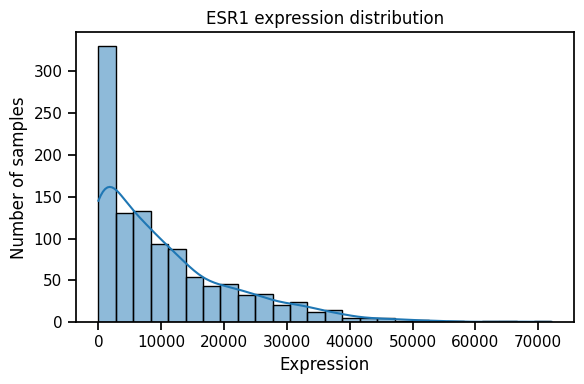

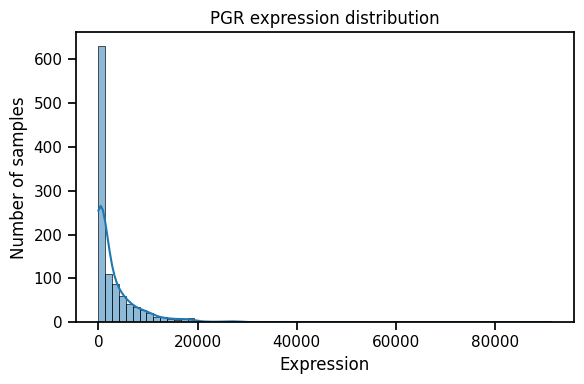

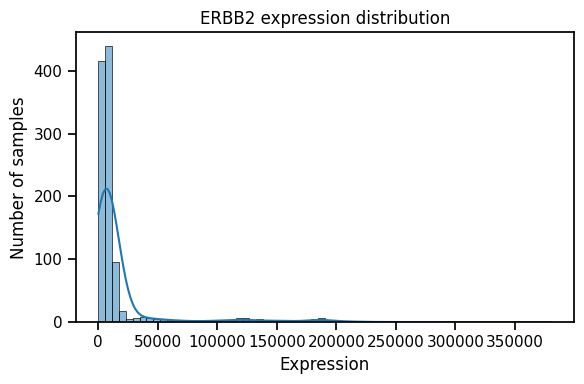

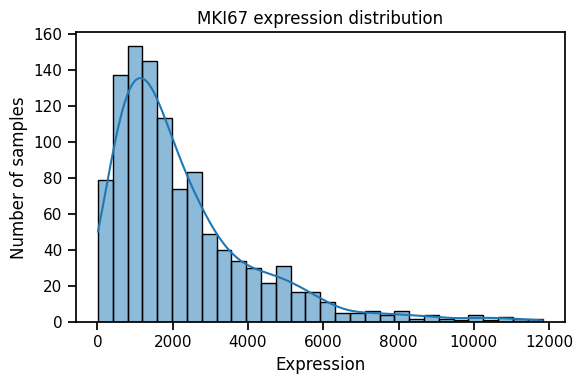

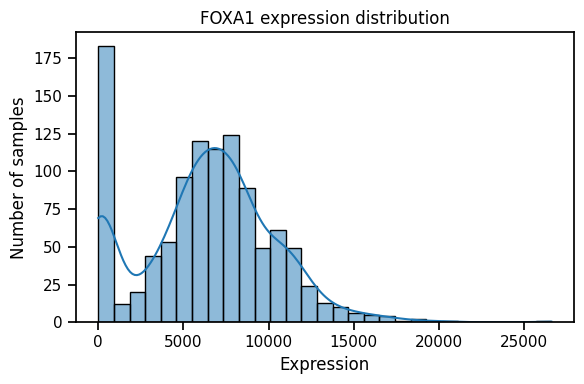

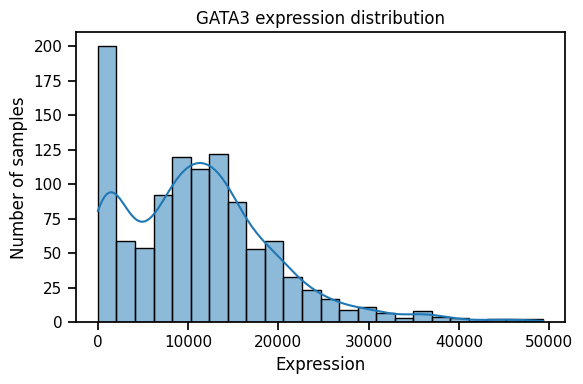

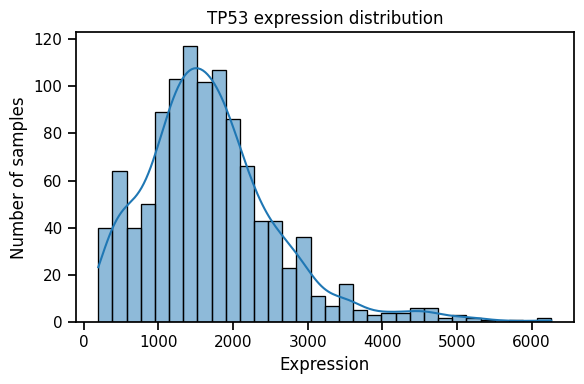

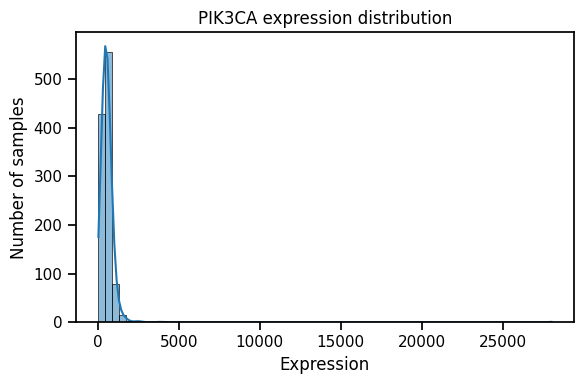

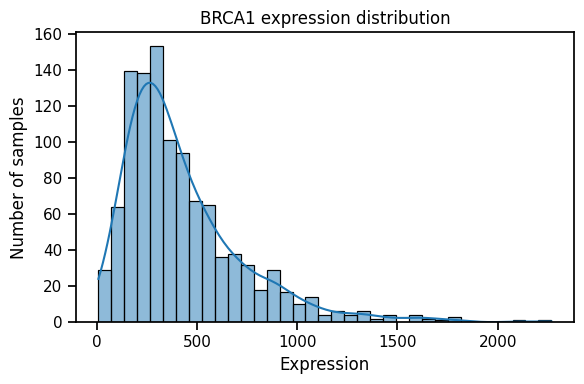

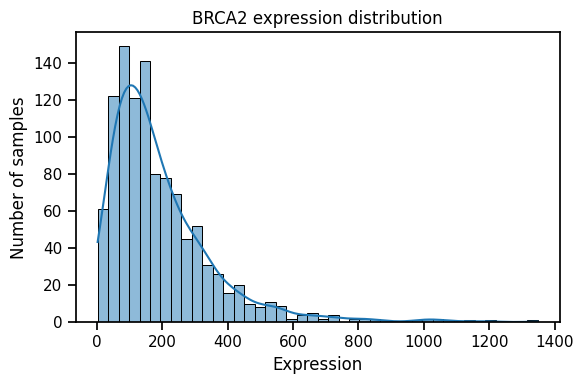

In [24]:
for gene in marker_genes:
    plt.figure(figsize=(6, 4))
    sns.histplot(markers[gene].dropna(), kde=True)
    plt.title(f"{gene} expression distribution")
    plt.xlabel("Expression")
    plt.ylabel("Number of samples")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{gene}_expression_distribution.png", dpi=300)
    plt.show()

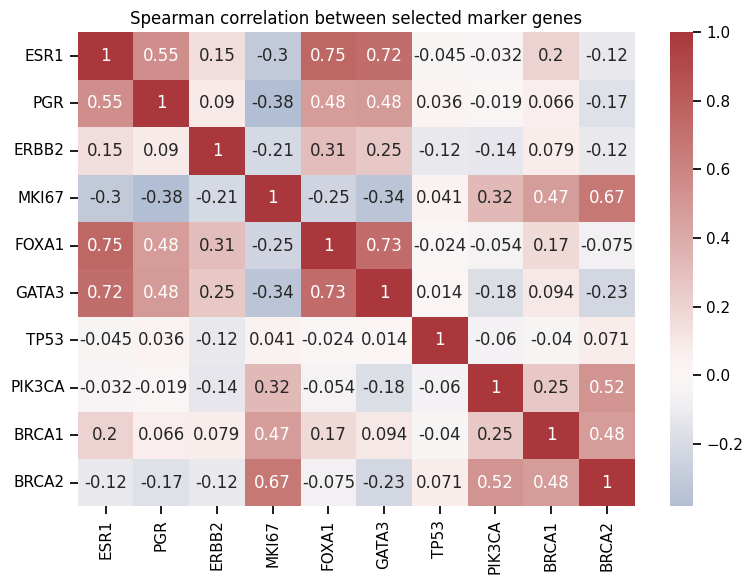

In [25]:
marker_corr = markers[marker_genes].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(marker_corr, annot=True, cmap="vlag", center=0)
plt.title("Spearman correlation between selected marker genes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "marker_gene_spearman_correlation.png", dpi=300)
plt.show()

marker_corr.to_csv(TABLES_DIR / "marker_gene_spearman_correlation.csv")

In [26]:
print("Metadata ID columns:")
display([col for col in metadata.columns if "SAMPLE" in col.upper() or "PATIENT" in col.upper()])

print("Marker ID columns:")
display([col for col in markers.columns if "SAMPLE" in col.upper() or "PATIENT" in col.upper()])

Metadata ID columns:


['PATIENT_ID_sample',
 'SAMPLE_ID',
 'SAMPLE_TYPE',
 'SAMPLE_ID_ORIGINAL_x',
 'SAMPLE_ID_15',
 'PATIENT_ID_12',
 'PATIENT_ID_patient',
 'OTHER_PATIENT_ID',
 'SAMPLE_ID_ORIGINAL_y']

Marker ID columns:


['SAMPLE_ID_ORIGINAL', 'SAMPLE_ID_15', 'PATIENT_ID_12']

In [27]:
analysis_df = metadata.merge(
    markers,
    on=["SAMPLE_ID_15", "PATIENT_ID_12"],
    how="inner",
    suffixes=("_clinical", "_marker")
)

print("analysis_df:", analysis_df.shape)
display(analysis_df.head())

analysis_df.to_csv(
    PROCESSED_DIR / "clinical_marker_analysis_table.tsv",
    sep="\t",
    index=False
)

analysis_df: (1082, 72)


,PATIENT_ID_sample,SAMPLE_ID,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,TUMOR_TYPE,GRADE,TISSUE_PROSPECTIVE_COLLECTION_INDICATOR,TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR,TISSUE_SOURCE_SITE_CODE,TUMOR_TISSUE_SITE,ANEUPLOIDY_SCORE,SAMPLE_TYPE,MSI_SCORE_MANTIS,MSI_SENSOR_SCORE,SOMATIC_STATUS,TMB_NONSYNONYMOUS,TISSUE_SOURCE_SITE,TBL_SCORE,SAMPLE_ID_ORIGINAL_x,SAMPLE_ID_15,PATIENT_ID_12,PATIENT_ID_patient,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,ETHNICITY,FORM_COMPLETION_DATE,HISTORY_NEOADJUVANT_TRTYN,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,PATH_M_STAGE,PATH_N_STAGE,PATH_T_STAGE,PERSON_NEOPLASM_CANCER_STATUS,PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT,PRIOR_DX,RACE,RADIATION_THERAPY,WEIGHT,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL,SAMPLE_ID_ORIGINAL_y,SAMPLE_ID_ORIGINAL,ESR1,PGR,ERBB2,MKI67,FOXA1,GATA3,TP53,PIK3CA,BRCA1,BRCA2
0,TCGA-3C-AAAU,TCGA-3C-AAAU-01,ILC,Breast Cancer,Breast Invasive Lobular Carcinoma,Infiltrating Lobular Carcinoma,NaN,No,Yes,3C,Breast,19.0,Primary,0.3319,0.55,Matched,0.800000,Columbia University,205.0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,TCGA-3C-AAAU,BRCA_LumA,BRCA,6E7D5EC6-A469-467C-B748-237353C23416,55,Female,STAGE X,6TH,4047.0,-20211.0,0,Not Hispanic Or Latino,1/13/14,No,C50.9,8520/3,C50.9,Yes,No,MX,NX,TX,With Tumor,Yes,No,White,No,NaN,Yes,0:LIVING,133.050597,0:ALIVE OR DEAD TUMOR FREE,133.050597,1:Recurred/Progressed,59.440444,1:PROGRESSION,59.440444,EUR,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,3457.9600,2273.2700,7113.41,2582.870,5448.37,14337.50,1385.530,487.003,831.317,178.878
1,TCGA-3C-AALI,TCGA-3C-AALI-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,22.0,Primary,0.3449,0.74,Matched,15.266667,Columbia University,190.0,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,TCGA-3C-AALI,BRCA_Her2,BRCA,55262FCB-1B01-4480-B322-36570430C917,50,Female,STAGE IIB,6TH,4005.0,-18538.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N1A,T2,Tumor Free,Yes,No,Black or African American,Yes,NaN,Yes,0:LIVING,131.669790,0:ALIVE OR DEAD TUMOR FREE,131.669790,0:DiseaseFree,131.669790,0:CENSORED,131.669790,AFR,TCGA-3C-AALI-01,TCGA-3C-AALI-01,68.5155,27.1887,194625.00,2285.480,6049.48,7437.74,414.356,321.914,389.886,153.888
2,TCGA-3C-AALJ,TCGA-3C-AALJ-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,13.0,Primary,0.3266,0.31,Matched,0.933333,Columbia University,365.0,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,TCGA-3C-AALJ,BRCA_LumB,BRCA,427D0648-3F77-4FFC-B52C-89855426D647,62,Female,STAGE IIB,7TH,1474.0,-22848.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N1A,T2,Tumor Free,Yes,No,Black or African American,No,NaN,Yes,0:LIVING,48.459743,0:ALIVE OR DEAD TUMOR FREE,48.459743,0:DiseaseFree,48.459743,0:CENSORED,48.459743,AFR_ADMIX,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,7482.3200,473.8350,11070.70,949.229,4620.13,10252.90,1289.210,216.682,200.363,151.405
3,TCGA-3C-AALK,TCGA-3C-AALK-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,4.0,Primary,0.3218,0.03,Matched,1.500000,Columbia University,25.0,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,TCGA-3C-AALK,BRCA_LumA,BRCA,C31900A4-5DCD-4022-97AC-638E86E889E4,52,Female,STAGE IA,7TH,1448.0,-19074.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N0 (I+),T1C,Tumor Free,Yes,No,Black or African American,No,NaN,Yes,0:LIVING,47.604958,0:ALIVE OR DEAD TUMOR FREE,47.604958,NaN,NaN,0:CENSORED,47.604958,AFR,TCGA-3C-AALK-01,TCGA-3C-AALK-01,2485.3100,2236.4600,36022.80,1139.430,7352.09,8761.69,1418.290,326.024,148.118,102.193
4,TCGA-4H-AAAK,TCGA-4H-AAAK-01,ILC,Breast Cancer,Breast Invasive Lobular Carcinoma,

In [28]:
for col in candidate_cols:
    n_unique = analysis_df[col].nunique(dropna=True)
    
    if n_unique <= 20:
        print(f"\n{col} — {n_unique} unique values")
        display(analysis_df[col].value_counts(dropna=False).head(20))


CANCER_TYPE — 1 unique values


CANCER_TYPE
Breast Cancer    1082
Name: count, dtype: int64


CANCER_TYPE_DETAILED — 6 unique values


CANCER_TYPE_DETAILED
Breast Invasive Ductal Carcinoma            780
Breast Invasive Lobular Carcinoma           201
Breast Invasive Carcinoma (NOS)              75
Breast Invasive Mixed Mucinous Carcinoma     17
Metaplastic Breast Cancer                     8
Invasive Breast Carcinoma                     1
Name: count, dtype: int64


GRADE — 0 unique values


...

DSS_STATUS
0:ALIVE OR DEAD TUMOR FREE    979
1:DEAD WITH TUMOR              83
NaN                            20
Name: count, dtype: int64


DFS_STATUS — 2 unique values


DFS_STATUS
0:DiseaseFree            856
NaN                      142
1:Recurred/Progressed     84
Name: count, dtype: int64


PFS_STATUS — 2 unique values


PFS_STATUS
0:CENSORED       936
1:PROGRESSION    145
NaN                1
Name: count, dtype: int64

In [29]:
def plot_marker_by_group(df, group_col, genes, min_group_size=10):
    counts = df[group_col].value_counts(dropna=True)
    valid_groups = counts[counts >= min_group_size].index
    
    plot_df = df[df[group_col].isin(valid_groups)].copy()
    
    for gene in genes:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=plot_df, x=group_col, y=gene)
        sns.stripplot(data=plot_df, x=group_col, y=gene, color="black", alpha=0.25, size=2)
        plt.title(f"{gene} expression by {group_col}")
        plt.xlabel(group_col)
        plt.ylabel("Expression")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        
        safe_group = group_col.replace("/", "_").replace(" ", "_")
        plt.savefig(FIGURES_DIR / f"{gene}_by_{safe_group}.png", dpi=300)
        plt.show()

In [30]:
marker_genes = [
    "ESR1",
    "PGR",
    "ERBB2",
    "MKI67",
    "FOXA1",
    "GATA3",
    "TP53",
    "PIK3CA",
    "BRCA1",
    "BRCA2",
]

marker_genes = [gene for gene in marker_genes if gene in analysis_df.columns]

print("Marker genes available in analysis_df:")
print(marker_genes)

Marker genes available in analysis_df:
['ESR1', 'PGR', 'ERBB2', 'MKI67', 'FOXA1', 'GATA3', 'TP53', 'PIK3CA', 'BRCA1', 'BRCA2']


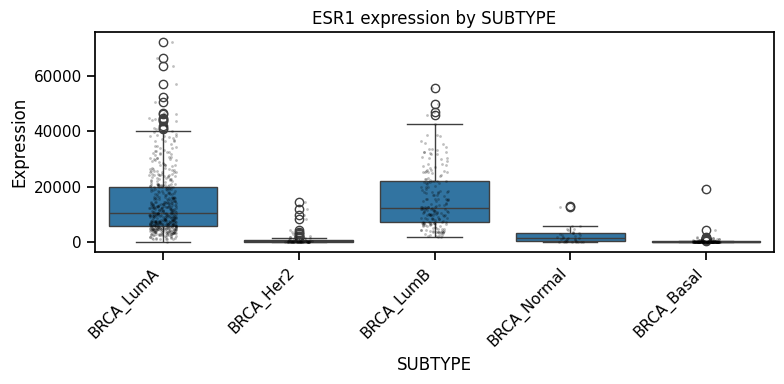

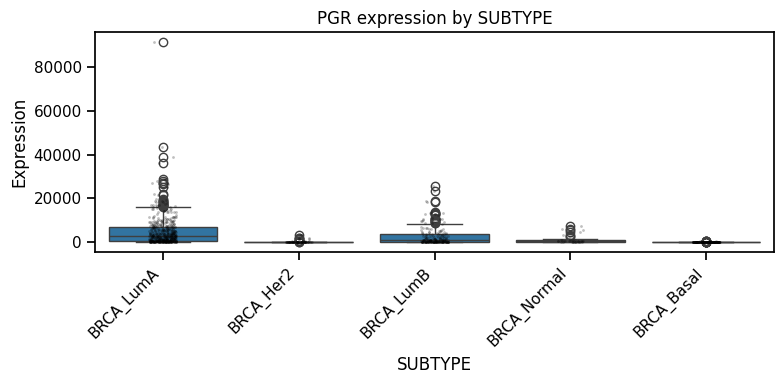

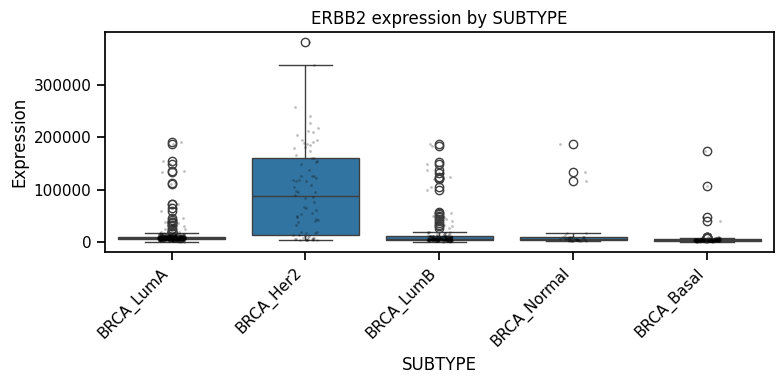

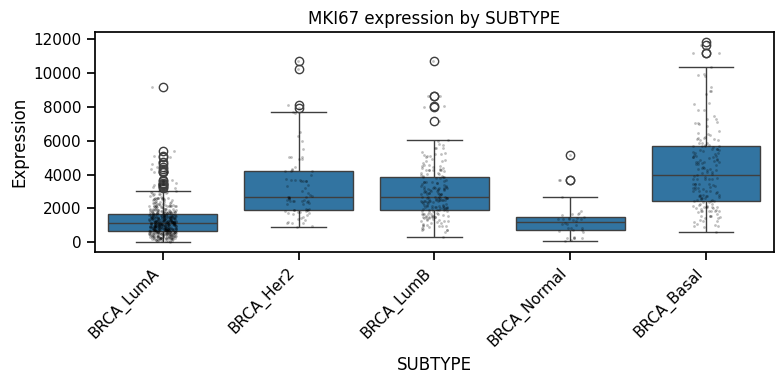

In [31]:
# Replace this after inspecting candidate columns
group_col = None

# Example:
#group_col = "PAM50"
group_col = "SUBTYPE"

if group_col is not None:
    plot_marker_by_group(
        analysis_df,
        group_col=group_col,
        genes=[gene for gene in ["ESR1", "PGR", "ERBB2", "MKI67"] if gene in marker_genes],
    )
else:
    print("Choose a group_col after inspecting candidate clinical columns.")

In [32]:
marker_genes = [
    "ESR1",
    "PGR",
    "ERBB2",
    "MKI67",
    "FOXA1",
    "GATA3",
    "TP53",
    "PIK3CA",
    "BRCA1",
    "BRCA2",
]

marker_genes = [gene for gene in marker_genes if gene in analysis_df.columns]

for gene in marker_genes:
    analysis_df[f"log2_{gene}"] = np.log2(analysis_df[gene] + 1)

log_marker_genes = [f"log2_{gene}" for gene in marker_genes]

display(analysis_df[log_marker_genes].describe().T)

,count,mean,std,min,25%,50%,75%,max
log2_ESR1,1082.0,11.659785,3.193169,1.900838,10.290360,12.786700,13.931017,16.137457
log2_PGR,1082.0,8.975225,3.415918,0.000000,5.895428,9.507360,11.918525,16.479441
log2_ERBB2,1082.0,12.973266,1.496089,7.284051,12.128356,12.778548,13.397828,18.538178
log2_MKI67,1082.0,10.654337,1.298583,4.111248,9.896334,10.731773,11.542253,13.529504
log2_FOXA1,1082.0,11.625953,2.692150,0.740625,11.948097,12.669705,13.085901,14.699534
log2_GATA3,1082.0,12.664914,2.058738,2.517880,12.189433,13.377285,13.919201,15.590353
log2_TP53,1082.0,10.513878,0.861242,7.606494,10.133675,10.639046,11.048437,12.613039
log2_PIK3CA,1082.0,8.977254,0.763857,5.765654,8.589892,9.059068,9.430105,14.772124
log2_BRCA1,1082.0,8.403818,1.062898,3.253747,7.772616,8.420968,9.103993,11.147345
log2_BRCA2,1082.0,7.158038,1.221820,1.447632,6.403344,7.230994,7.969722,10.397643


In [ ]:
subtype_counts = (
    analysis_df["SUBTYPE"]
    .fillna("Unknown")
    .value_counts()
    .reset_index()
)

subtype_counts.columns = ["SUBTYPE", "n_samples"]

display(subtype_counts)

plt.figure(figsize=(7, 4))
sns.barplot(data=subtype_counts, x="SUBTYPE", y="n_samples")
plt.title("TCGA-BRCA samples by molecular subtype")
plt.xlabel("Molecular subtype")
plt.ylabel("Number of samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "subtype_distribution.png", dpi=300)
plt.show()

subtype_counts.to_csv(TABLES_DIR / "subtype_distribution.csv", index=False)